# IA escribe software científico expert-level

> Un sistema de IA puso 30 modelos diseñados por humanos detrás de sí en un benchmark público de pronóstico de series temporales (forecasting). Y en segmentación de imágenes satelitales, sus tres soluciones le ganaron a cinco papers publicados entre 2021 y 2025.

**Paper:** [An AI system to help scientists write expert-level empirical software](https://doi.org/10.1038/s41586-026-10658-6) · *Nature* (2026)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-19-ia-software-cientifico-experto/notebook.ipynb)

**Video:** [Pendiente]


## Lo que mira el notebook

El equipo (Google DeepMind, Google Research, MIT, Harvard, McGill, Caltech) construyó **ERA** (*Empirical Research Assistance*): un sistema que combina un modelo de lenguaje (LLM) con búsqueda en árbol (*Tree Search*) para escribir software que maximiza una métrica de calidad.

Lo probaron en seis tareas. En este notebook abrimos las tablas del *Supplementary* para tres comparaciones concretas: el leaderboard de GIFT-Eval (la tabla pública de pronóstico de series temporales), el benchmark DLRSD (la prueba estándar de segmentación de imágenes satelitales) y el presupuesto computacional. El paper afirma que ERA "alcanza nivel experto" — los datos del SI nos dejan ponerle números a esa frase.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ERA_PER_DATASET_MASE = 0.671          # Mejor MASE de ERA en GIFT-Eval
ERA_UNIFIED_MASE = 0.734              # Segunda submission ERA
SEASONAL_NAIVE_BASELINE = 1.0         # MASE=1 = igual de bueno que naive
DLRSD_BEST_PAPER_MIOU = 0.762         # RE-Net (2021), mejor paper previo
FUENTE = "Fuente: Aygün et al. (2026), Nature | Datos: Supplementary Tables S1, S12, S14"

COLOR_ERA = "#DC2626"                 # Rojo CaM — protagonista
COLOR_HUMANO = "#2563EB"              # Azul CaM — resto
COLOR_REF = "#D97706"                 # Ámbar — referencia/baseline
COLOR_CONTEXTO = "#BBBBBB"            # Gris — contexto histórico

# Imports + estilo
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

style_file = "../../cam.mplstyle"
if not os.path.exists(style_file):
    style_file = "/tmp/cam.mplstyle"
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle",
            style_file,
        )
plt.style.use(style_file)

# Carga de las tres tablas del Supplementary
gift = pd.read_csv("datos/gift_eval_leaderboard.csv")
dlrsd = pd.read_csv("datos/dlrsd_benchmark.csv")
compute = pd.read_csv("datos/computational_budget.csv")

print(f"GIFT-Eval: {len(gift)} modelos · MASE rango [{gift['mase'].min():.3f}, {gift['mase'].max():.3f}]")
print(f"DLRSD: {len(dlrsd)} métodos · {(dlrsd['source']=='ERA').sum()} ERA vs {(dlrsd['source']=='paper').sum()} papers previos")
print(f"Cómputo: {len(compute)} tareas · total {compute['duration_min'].sum():.1f} min ({compute['duration_min'].sum()/60:.1f} h)")


GIFT-Eval: 32 modelos · MASE rango [0.671, 2.310]
DLRSD: 8 métodos · 3 ERA vs 5 papers previos
Cómputo: 6 tareas · total 272.6 min (4.5 h)


## El leaderboard de forecasting

Aquí está.


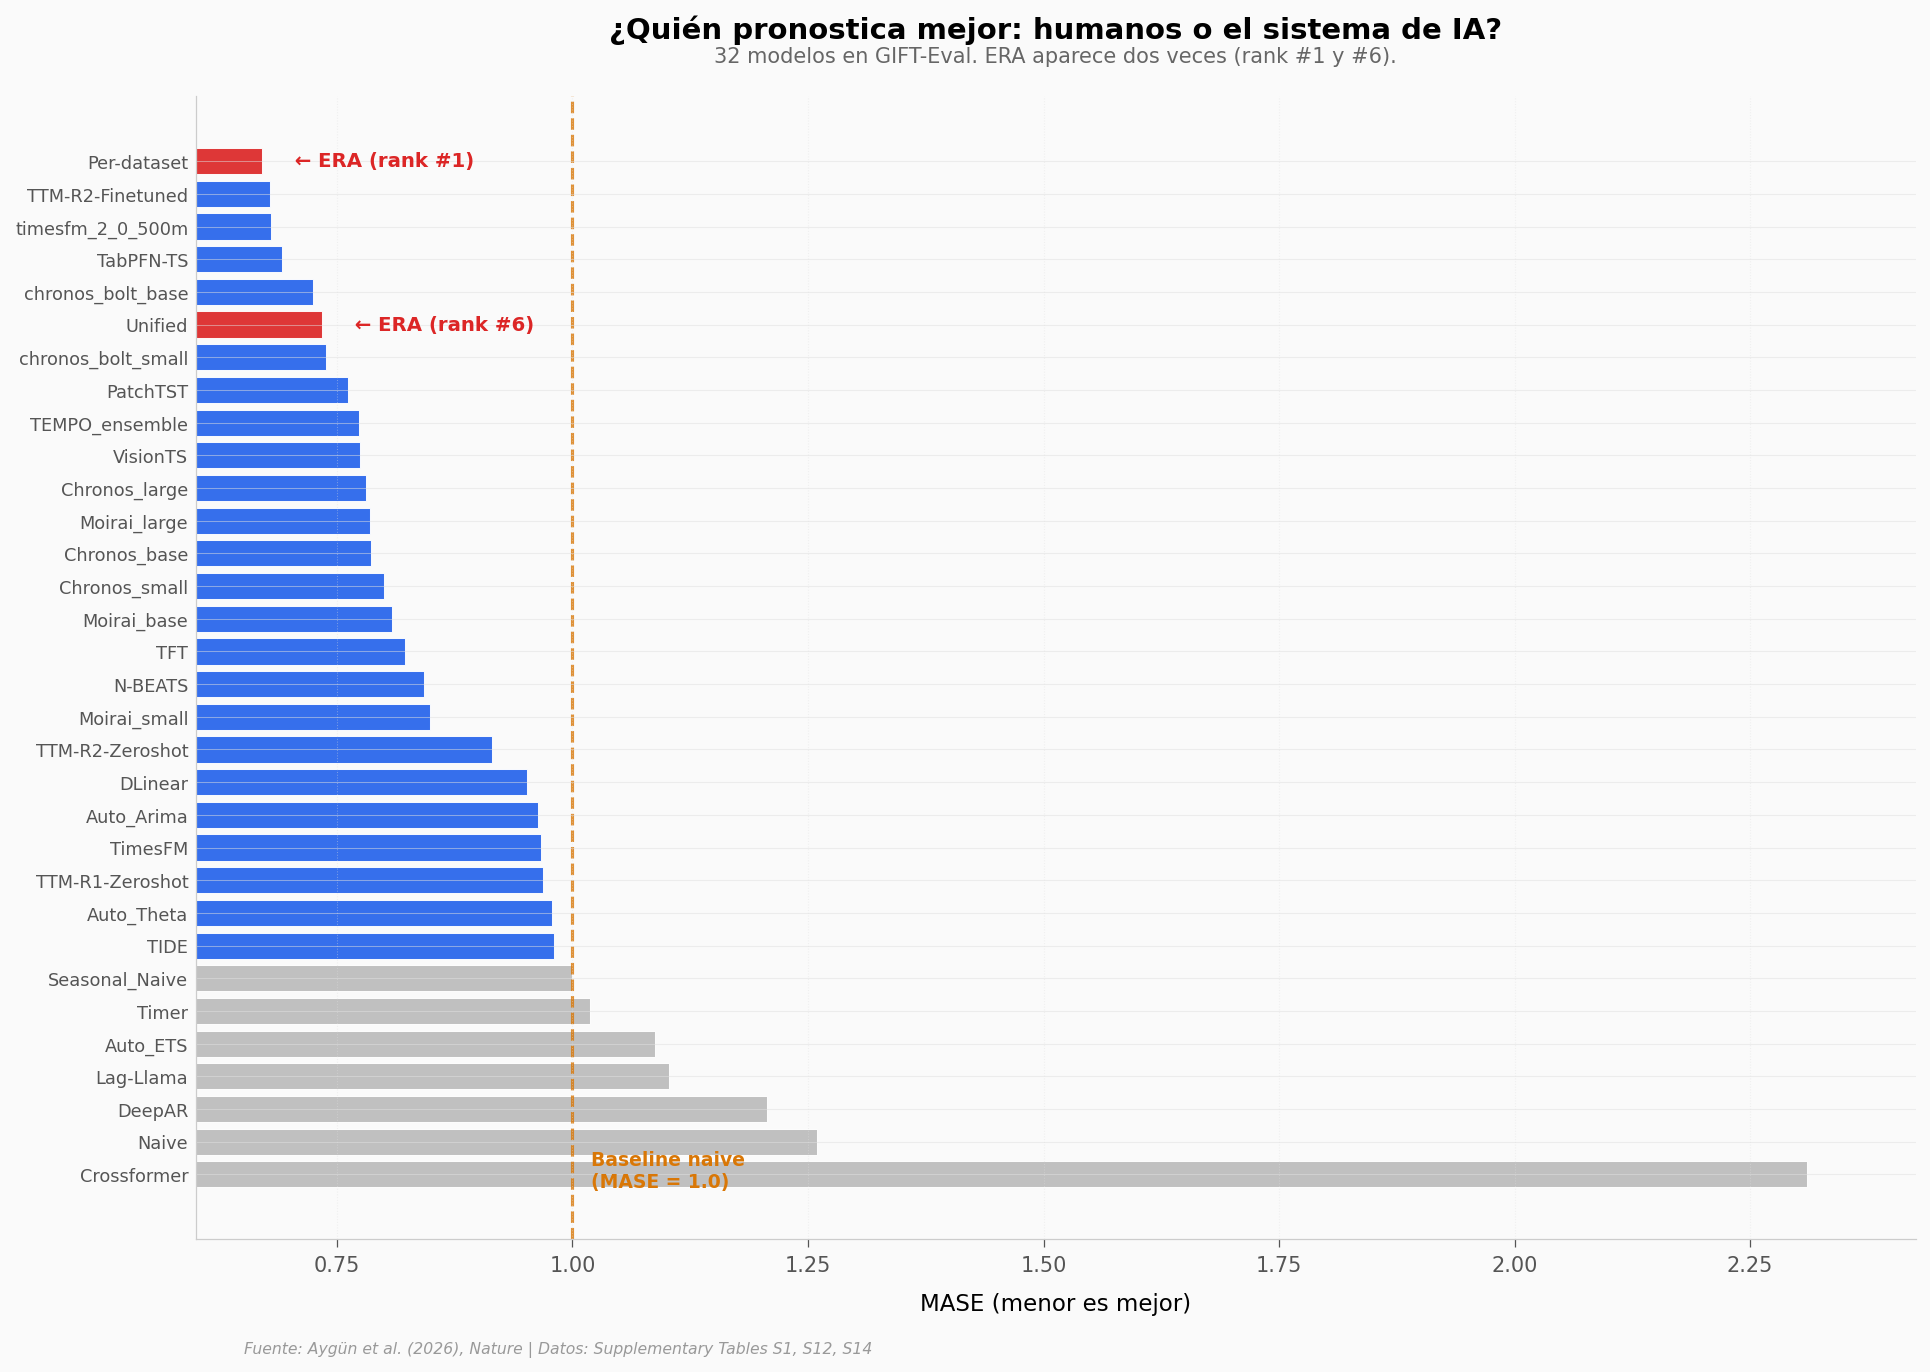

In [2]:
gift_sorted = gift.sort_values("mase", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 9))

# Colorear: ERA en rojo, resto en azul/gris según tipo
def color_for_row(row):
    if row["type"] == "ERA":
        return COLOR_ERA
    if row["mase"] >= SEASONAL_NAIVE_BASELINE:
        return COLOR_CONTEXTO  # peor o igual que naive
    return COLOR_HUMANO

colors = [color_for_row(r) for _, r in gift_sorted.iterrows()]

y_pos = np.arange(len(gift_sorted))
ax.barh(y_pos, gift_sorted["mase"], color=colors,
        edgecolor="white", linewidth=0.5, alpha=0.92)

ax.set_yticks(y_pos)
ax.set_yticklabels(gift_sorted["model"], fontsize=8.5)
ax.invert_yaxis()  # mejor arriba

# Línea de referencia: baseline Seasonal Naive
ax.axvline(x=SEASONAL_NAIVE_BASELINE, color=COLOR_REF, linewidth=1.5,
           linestyle="--", alpha=0.8, zorder=1)
ax.text(SEASONAL_NAIVE_BASELINE + 0.02, len(gift_sorted) - 0.5,
        f"Baseline naive\n(MASE = {SEASONAL_NAIVE_BASELINE})",
        fontsize=9, color=COLOR_REF, fontweight="bold", va="bottom")

# Etiquetas inline ERA
for idx, row in gift_sorted.iterrows():
    if row["type"] == "ERA":
        ax.text(row["mase"] + 0.02, idx,
                f"  ← ERA (rank #{idx+1})",
                fontsize=9.5, color=COLOR_ERA, fontweight="bold",
                va="center")

ax.set_xlabel("MASE (menor es mejor)", fontsize=11)
ax.set_title("¿Quién pronostica mejor: humanos o el sistema de IA?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        f"32 modelos en GIFT-Eval. ERA aparece dos veces (rank #1 y #6).",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

ax.set_xlim(0.6, max(gift_sorted["mase"]) * 1.05)
ax.grid(axis="x", linestyle=":", alpha=0.4)

fig.text(0.13, -0.01, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/leaderboard_gift_eval.png", dpi=200, bbox_inches="tight")
plt.show()


## Cómo leer la tabla

ERA Per-dataset queda primero con MASE = 0.671 frente a 31 alternativas humanas. ERA Unified queda sexto. Por encima de la línea naranja (baseline *Seasonal Naive*, MASE = 1.0) los modelos en gris no le ganan al método más simple imaginable — sirven como recordatorio de que "modelo" no equivale a "mejor que adivinar".

Lo interesante no es solo que ERA gane: es que **los 30 puestos restantes (descontando las dos submissions de ERA) son sistemas diseñados por equipos humanos especializados** — pretrained foundation models, deep learning, modelos estadísticos clásicos. El sistema de IA escribiendo software los acomodó por debajo.


## El zoom: ¿qué tan apretada está la cima?

La diferencia con el segundo puesto importa: no es lo mismo ganar por una nariz que aplastar al resto. Veamos el top 6.


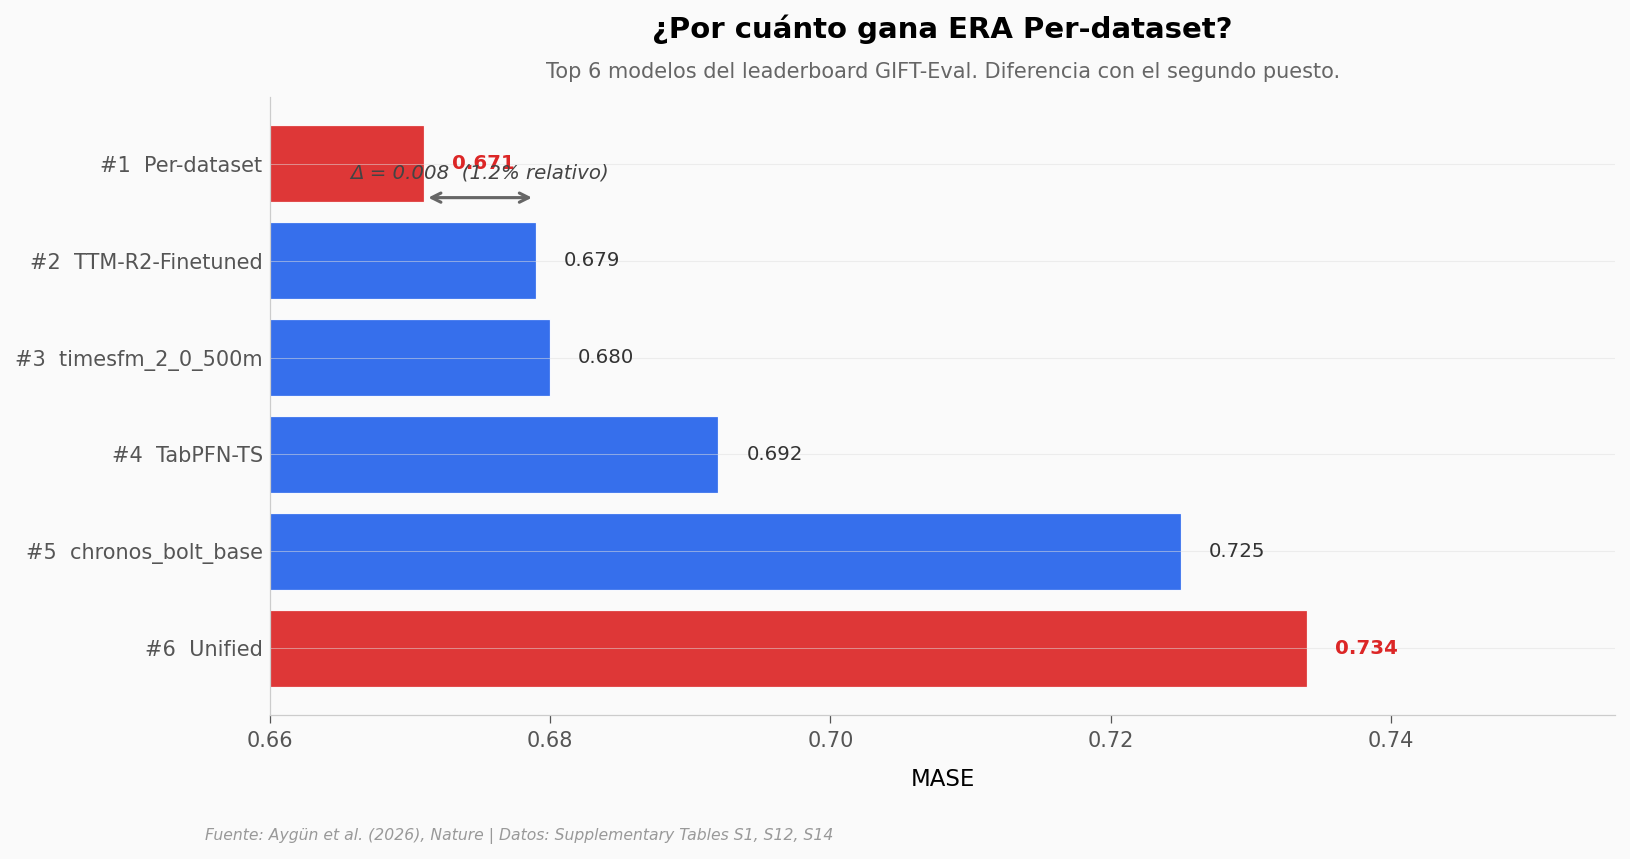


ERA Per-dataset MASE = 0.671
Segundo puesto (TTM-R2-Finetuned) MASE = 0.679
Ventaja relativa: 1.19%


In [3]:
top6 = gift_sorted.head(6).copy()
top6["rank"] = top6.index + 1

fig, ax = plt.subplots(figsize=(11, 5.5))

colors_top = [COLOR_ERA if t == "ERA" else COLOR_HUMANO for t in top6["type"]]
bars = ax.barh(np.arange(len(top6)), top6["mase"], color=colors_top,
               edgecolor="white", linewidth=0.6, alpha=0.92)
ax.set_yticks(np.arange(len(top6)))
ax.set_yticklabels([f"#{r}  {m}" for r, m in zip(top6["rank"], top6["model"])],
                   fontsize=10)
ax.invert_yaxis()

# Anotar el MASE de cada barra
for i, (mase, t) in enumerate(zip(top6["mase"], top6["type"])):
    ax.text(mase + 0.002, i, f"{mase:.3f}",
            va="center", fontsize=9.5,
            color=COLOR_ERA if t == "ERA" else "#333333",
            fontweight="bold" if t == "ERA" else "normal")

# Flecha bidireccional entre #1 y #2 mostrando el gap
gap_abs = top6["mase"].iloc[1] - top6["mase"].iloc[0]
gap_pct = 100 * gap_abs / top6["mase"].iloc[0]
ax.annotate("",
            xy=(top6["mase"].iloc[0], 0.35), xytext=(top6["mase"].iloc[1], 0.35),
            arrowprops=dict(arrowstyle="<->", color="#666666", lw=1.5))
ax.text((top6["mase"].iloc[0] + top6["mase"].iloc[1]) / 2, 0.15,
        f"Δ = {gap_abs:.3f}  ({gap_pct:.1f}% relativo)",
        ha="center", fontsize=9.5, color="#444444", style="italic")

ax.set_xlim(0.66, top6["mase"].max() * 1.03)
ax.set_xlabel("MASE", fontsize=11)
ax.set_title("¿Por cuánto gana ERA Per-dataset?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "Top 6 modelos del leaderboard GIFT-Eval. Diferencia con el segundo puesto.",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/top6_zoom.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nERA Per-dataset MASE = {top6['mase'].iloc[0]:.3f}")
print(f"Segundo puesto ({top6['model'].iloc[1]}) MASE = {top6['mase'].iloc[1]:.3f}")
print(f"Ventaja relativa: {gap_pct:.2f}%")


## Otra batalla, otro deporte

GIFT-Eval es una arena bien comprendida — tiene un leaderboard, métrica única, decenas de modelos. La segunda comparación es más áspera: **segmentación geoespacial DLRSD**, donde el "estado del arte" se publica como papers individuales con su propia arquitectura.

ERA mandó tres soluciones. Los cinco mejores resultados publicados entre 2021 y 2025 estaban ahí esperando.


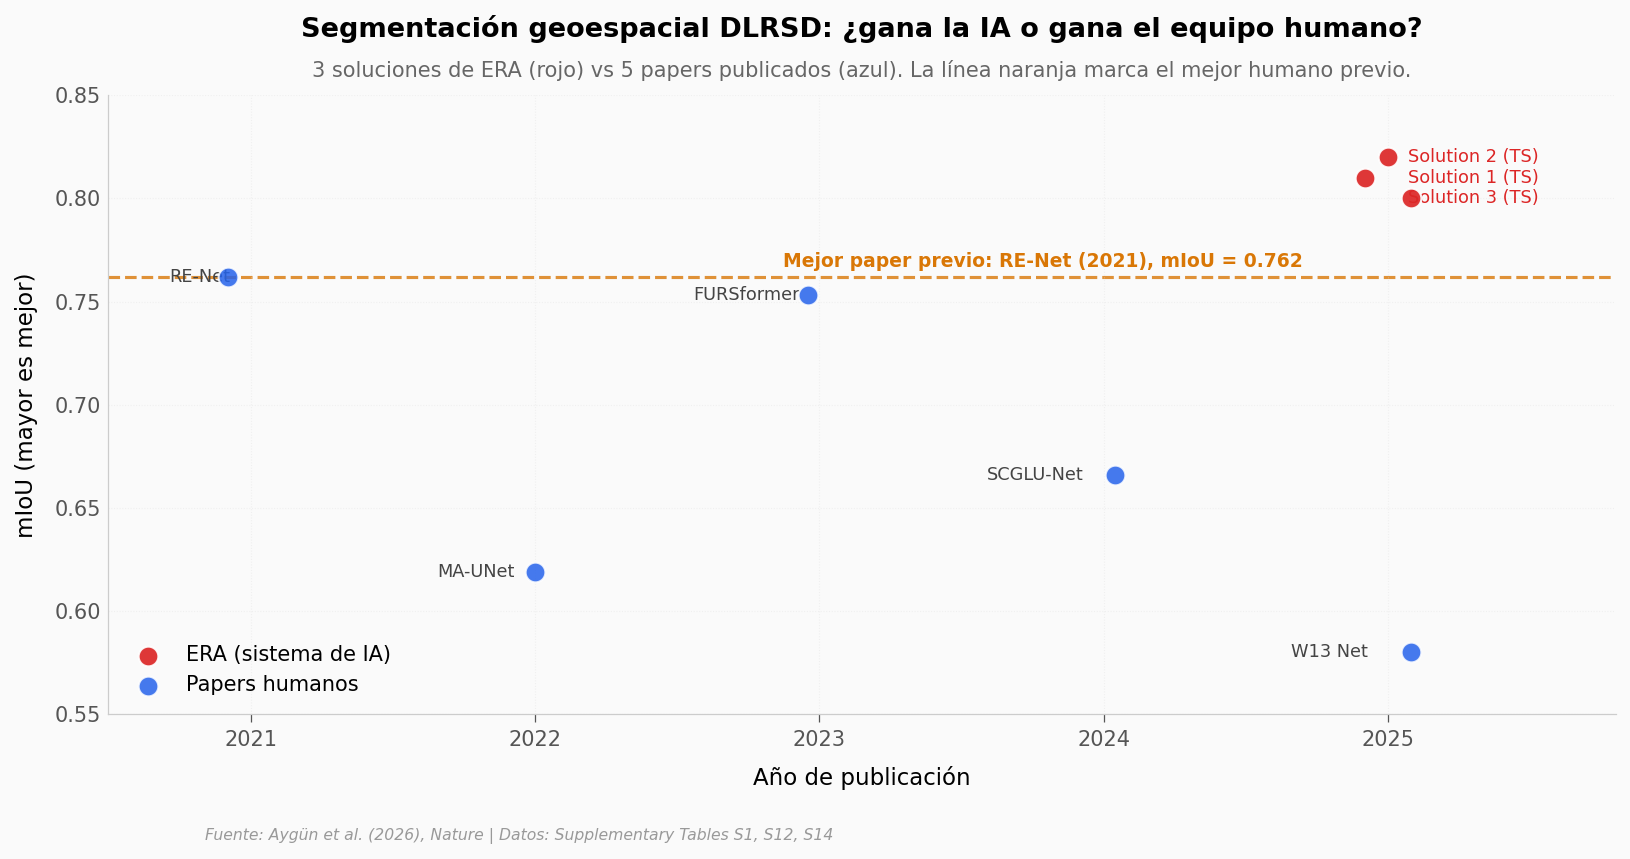


ERA: mIoU rango [0.800, 0.820], media = 0.810
Papers previos: mIoU rango [0.580, 0.762], media = 0.676
Peor ERA (0.80) vs mejor paper (0.762): gap = +0.038


In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Separar grupos
era_mask = dlrsd["source"] == "ERA"
papers_mask = dlrsd["source"] == "paper"

# Scatter ERA vs papers (jitter horizontal mínimo para evitar overlap)
np.random.seed(42)
jitter_era = np.linspace(-0.08, 0.08, era_mask.sum())
np.random.shuffle(jitter_era)
jitter_papers = np.linspace(-0.08, 0.08, papers_mask.sum())
np.random.shuffle(jitter_papers)

ax.scatter(dlrsd.loc[era_mask, "year"] + jitter_era,
           dlrsd.loc[era_mask, "miou"],
           color=COLOR_ERA, s=90, alpha=0.92,
           edgecolors="white", linewidths=1.0,
           zorder=5, label="ERA (sistema de IA)")
ax.scatter(dlrsd.loc[papers_mask, "year"] + jitter_papers,
           dlrsd.loc[papers_mask, "miou"],
           color=COLOR_HUMANO, s=90, alpha=0.85,
           edgecolors="white", linewidths=1.0,
           zorder=4, label="Papers humanos")

# Línea horizontal: mejor paper previo
ax.axhline(y=DLRSD_BEST_PAPER_MIOU, color=COLOR_REF, linewidth=1.5,
           linestyle="--", alpha=0.8, zorder=1)
ax.text(2024.7, DLRSD_BEST_PAPER_MIOU + 0.005,
        f"Mejor paper previo: RE-Net (2021), mIoU = {DLRSD_BEST_PAPER_MIOU}",
        fontsize=9, color=COLOR_REF, fontweight="bold", ha="right")

# Etiquetar cada punto con el nombre del método
for _, row in dlrsd.iterrows():
    offset_x = 0.07 if row["source"] == "ERA" else -0.07
    ha = "left" if row["source"] == "ERA" else "right"
    ax.text(row["year"] + offset_x, row["miou"],
            row["method"],
            fontsize=8.5, va="center", ha=ha,
            color=COLOR_ERA if row["source"] == "ERA" else "#444444")

ax.set_xlabel("Año de publicación", fontsize=11)
ax.set_ylabel("mIoU (mayor es mejor)", fontsize=11)
ax.set_title("Segmentación geoespacial DLRSD: ¿gana la IA o gana el equipo humano?",
             fontsize=13, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "3 soluciones de ERA (rojo) vs 5 papers publicados (azul). La línea naranja marca el mejor humano previo.",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

ax.set_xlim(2020.5, 2025.8)
ax.set_ylim(0.55, 0.85)
ax.legend(fontsize=10, loc="lower left", framealpha=0.9)
ax.grid(linestyle=":", alpha=0.4)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/dlrsd_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

# Resumen numérico
era_miou = dlrsd.loc[era_mask, "miou"]
papers_miou = dlrsd.loc[papers_mask, "miou"]
print(f"\nERA: mIoU rango [{era_miou.min():.3f}, {era_miou.max():.3f}], media = {era_miou.mean():.3f}")
print(f"Papers previos: mIoU rango [{papers_miou.min():.3f}, {papers_miou.max():.3f}], media = {papers_miou.mean():.3f}")
print(f"Peor ERA ({era_miou.min():.2f}) vs mejor paper ({papers_miou.max():.3f}): gap = {era_miou.min() - papers_miou.max():+.3f}")


## ¿Qué tan rara es ese MASE de 0.671?

Una cifra puede ser baja porque hay un montón de cifras bajas — o porque está sola. Veamos dónde cae ERA Per-dataset frente a la distribución de los otros 31 modelos del leaderboard.


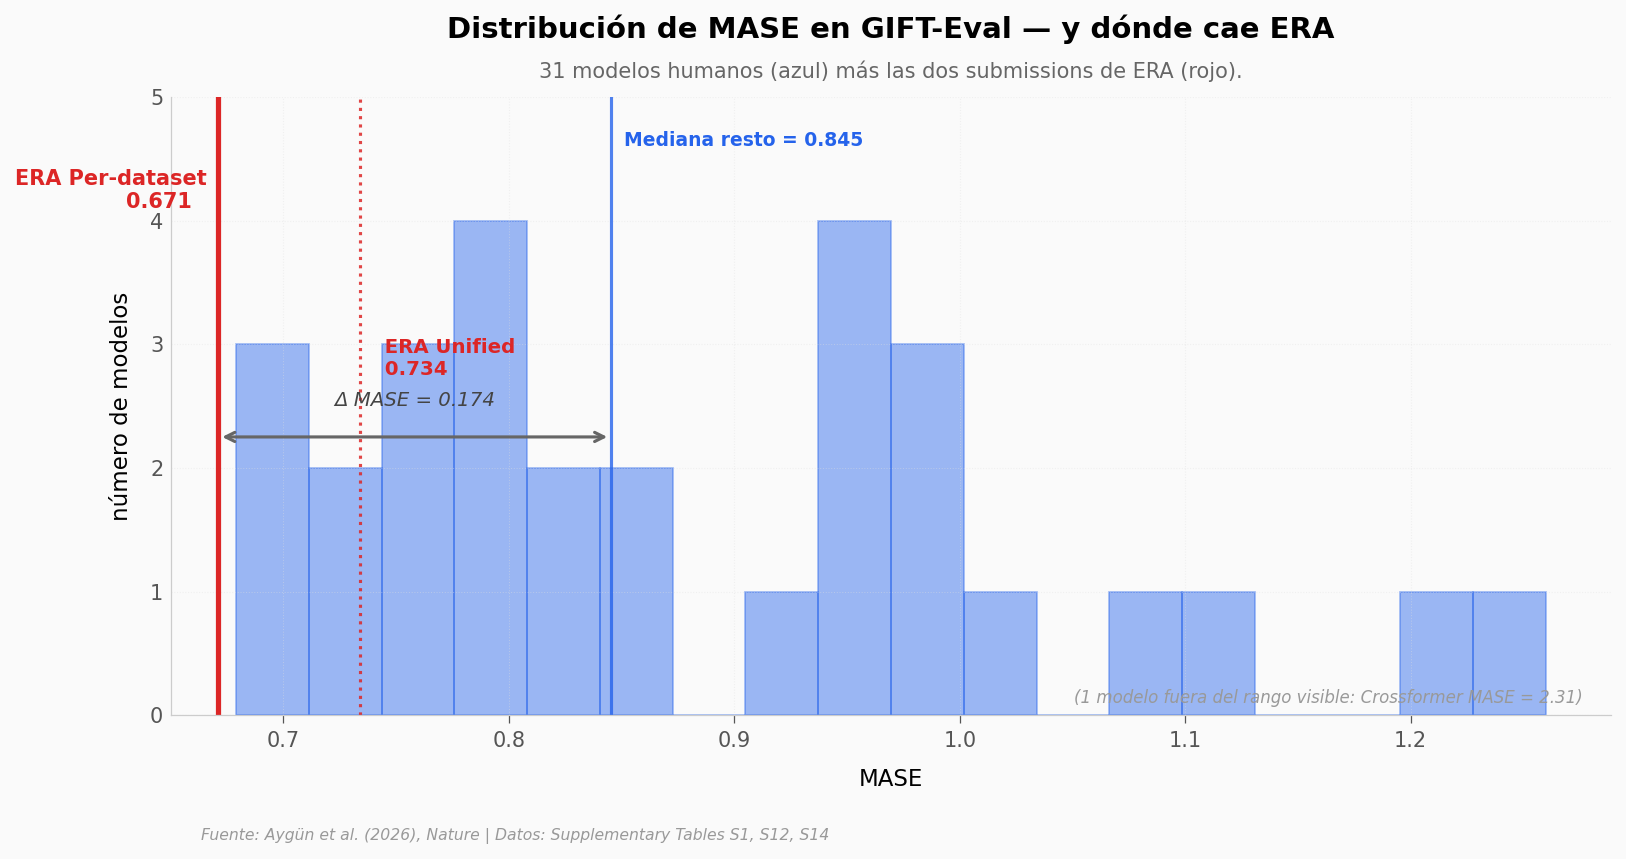

In [5]:
otros = gift_sorted[gift_sorted["type"] != "ERA"]["mase"].values
era_per = ERA_PER_DATASET_MASE
era_uni = ERA_UNIFIED_MASE

# Truncar para que el histograma no se aplane por el outlier (Crossformer 2.31)
otros_view = otros[otros <= 1.5]

fig, ax = plt.subplots(figsize=(11, 5.5))
n, bins, _ = ax.hist(otros_view, bins=18, color=COLOR_HUMANO, alpha=0.45,
                     edgecolor=COLOR_HUMANO, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Mediana de los otros
mediana_otros = np.median(otros)
ax.axvline(x=mediana_otros, color=COLOR_HUMANO, linewidth=1.5, alpha=0.8)
ax.text(mediana_otros, y_max * 0.92, f"  Mediana resto = {mediana_otros:.3f}",
        fontsize=9, color=COLOR_HUMANO, fontweight="bold")

# ERA Per-dataset
ax.axvline(x=era_per, color=COLOR_ERA, linewidth=2.5)
ax.text(era_per - 0.005, y_max * 0.82, f"ERA Per-dataset\n{era_per}  ",
        fontsize=10, color=COLOR_ERA, fontweight="bold", ha="right")

# ERA Unified
ax.axvline(x=era_uni, color=COLOR_ERA, linewidth=1.5, linestyle=":", alpha=0.85)
ax.text(era_uni + 0.005, y_max * 0.55, f"  ERA Unified\n  {era_uni}",
        fontsize=9.5, color=COLOR_ERA, fontweight="bold")

# Flecha bidireccional entre ERA Per-dataset y mediana
ax.annotate("", xy=(era_per, y_max * 0.45),
            xytext=(mediana_otros, y_max * 0.45),
            arrowprops=dict(arrowstyle="<->", color="#666666", lw=1.5))
ax.text((era_per + mediana_otros) / 2, y_max * 0.50,
        f"Δ MASE = {mediana_otros - era_per:.3f}",
        ha="center", fontsize=9.5, color="#444444", style="italic")

# Nota sobre outlier truncado
if len(otros) > len(otros_view):
    ax.text(0.98, 0.02,
            f"({len(otros) - len(otros_view)} modelo fuera del rango visible: Crossformer MASE = {otros.max():.2f})",
            transform=ax.transAxes, fontsize=8, color="#999999",
            ha="right", style="italic")

ax.set_xlabel("MASE", fontsize=11)
ax.set_ylabel("número de modelos", fontsize=11)
ax.set_title("Distribución de MASE en GIFT-Eval — y dónde cae ERA",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "31 modelos humanos (azul) más las dos submissions de ERA (rojo).",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.grid(linestyle=":", alpha=0.4)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/distribucion_mase.png", dpi=200, bbox_inches="tight")
plt.show()


## Lo que los datos del Supplementary soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| ERA alcanza resultados nivel experto en GIFT-Eval | ✅ | ERA Per-dataset MASE = 0.671, rank #1 entre 32 modelos. ERA Unified rank #6. Ambos por debajo del baseline naive (MASE = 1.0). |
| ERA bate al segundo clasificado por un margen pequeño en forecasting | ✅ | Ventaja relativa = 1.19 % sobre TTM-R2-Finetuned (0.679). Es "consistente y de punta", no "aplastante". |
| ERA produce software expert-level para segmentación geoespacial | ✅ | Las 3 soluciones de ERA (mIoU 0.80–0.82) superan al mejor paper previo (RE-Net 2021, mIoU = 0.762) por ~5–8 % relativo. |
| ERA generó 40 métodos novedosos en single-cell que baten a top humanos | ⚠️ | El abstract lo afirma, el SI §1 lo describe cualitativamente, pero **no hay tabla completa reproducible** del ranking single-cell en el Supplementary. No verificable con datos abiertos. |
| ERA generó 14 modelos que baten al ensemble de la CDC en COVID-19 | ⚠️ | Mismo escenario: descrito en abstract y SI, sin tabla numérica completa abierta. |
| Sistema = LLM + Tree Search, con baselines incluidos en la búsqueda | ✅ | El paper describe el algoritmo y Tablas S13 lista componentes rule-based (seasonal_naive_baseline, additive_damped_linear, etc.) integrados en la búsqueda. |

> **Limitaciones honestas**
> - El leaderboard GIFT-Eval es un *snapshot* del 2025-05-18. Los benchmarks vivos cambian; otra release puede tener un nuevo #1.
> - Dos de las afirmaciones del abstract (single-cell y COVID-19) describen tablas que el SI no incluye con detalle numérico abierto.
> - "Expert-level" es la caracterización de los autores, no un test ciego de un comité independiente.
> - El paper no compara ERA contra otros agentes de IA que escriben código (AlphaCode, AutoML); solo contra baselines humanos del leaderboard.


## Ahora tú

Tres caminos para seguir explorando los datos:

1. **¿Qué tipo de modelo aparece más arriba en el ranking?** Agrupar `gift` por la columna `type` y comparar medias / cuartiles. Pista: `gift.groupby("type")["mase"].describe()`.
2. **¿Sale caro ese rank #1?** Cargar `compute` y comparar el tiempo de cómputo entre GIFT-Eval (53 min) y la tarea más lenta, ZAPBench (192 min). ¿Cuánto cuesta cada nodo del *Tree Search* en tokens?
3. **¿Y si DLRSD fuera más antiguo?** Filtrar `dlrsd` por `year <= 2022` y ver qué tan ajustada habría sido la comparación. Pista: `dlrsd[dlrsd["year"] <= 2022].sort_values("miou", ascending=False)`.


In [6]:
# --- EXPERIMENTA AQUÍ ---

# Pregunta 1: ¿qué tipo de modelo aparece más arriba?
print("MASE por tipo de modelo (menor es mejor):\n")
print(gift.groupby("type")["mase"].agg(["count", "min", "median", "max"]).round(3))

# Pregunta 2: cómputo por tarea
print("\n\nMinutos de cómputo total por tarea:\n")
print(compute[["task", "duration_min", "sandbox_type"]].sort_values("duration_min"))
print(f"\nTotal compute: {compute['duration_min'].sum():.1f} min ({compute['duration_min'].sum()/60:.1f} h)")


MASE por tipo de modelo (menor es mejor):

               count    min  median    max
type                                      
ERA                2  0.671   0.702  0.734
deep-learning      7  0.762   0.952  2.310
fine-tuned         2  0.679   0.726  0.773
pretrained        16  0.680   0.793  1.102
statistical        5  0.964   1.000  1.260


Minutos de cómputo total por tarea:

                task  duration_min sandbox_type
1  Covid Forecasting           1.2          CPU
3          Integrals           1.5          CPU
0  Batch Integration           8.0          GPU
4         Geospatial          16.4          GPU
2          GIFT-Eval          53.3          CPU
5           ZAPBench         192.2          GPU

Total compute: 272.6 min (4.5 h)


## Créditos

**Notebook:** Ciencia a Mordiscos · El Lab · 2026-05-20
**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
**Licencia:** datos del paper bajo licencia del editor (Nature); código del notebook bajo MIT.

## Fuentes

**Paper**: [An AI system to help scientists write expert-level empirical software](https://doi.org/10.1038/s41586-026-10658-6)  
*Nature, 2026-05-19*

**Supplementary Material**: [Supplementary Information for: An AI system to help scientists write expert-level empirical software (MOESM1) — incluye Tables S1, S12, S14](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10658-6/MediaObjects/41586_2026_10658_MOESM1_ESM.pdf)  
*Tables S1, S12, S14 — leaderboard GIFT-Eval, DLRSD y presupuesto de cómputo*

*20 afirmaciones del notebook verificadas contra estas fuentes*
